# Visualization Testing and Streamlit Planning 

## Purpose

This notebook develops and evaluates the visualizations that will be incorporated into the Rhabdomyosarcoma TMB & Survival Explorer. The goal is to determine which plots are informative, verify that they work with both sample-level and patient-level data, and identify the user controls needed for the final Streamlit application.

The notebook includes exploratory plots, missing-data summaries, patient/sample comparisons, and Kaplan–Meier survival visualizations. Each figure is built using Plotly so that it can later be transferred directly into Streamlit with minimal modification.

## Objectives

* Load cleaned sample-level and patient-level datasets.
* Compare sample-level and patient-level visualizations.
* Develop reusable plotting functions.
* Test histograms, boxplots, violin plots, scatterplots, and heatmaps.
* Create categorical frequency plots.
* Visualize sample counts and within-patient TMB variation.
* Test Kaplan–Meier survival figures.
* Identify suitable Streamlit controls for each visualization.
* Export selected figures for project documentation.

# Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Define project paths 

In [2]:
PROJECT_DIR = Path.cwd().parent

SAMPLE_DATA_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "sample_level_cleaned.tsv"
)

PATIENT_DATA_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "patient_level_mean.tsv"
)

SURVIVAL_DATA_FILE = (
    PROJECT_DIR
    / "results"
    / "survival"
    / "patient_survival_analysis_data.tsv"
)

FIGURE_DIR = (
    PROJECT_DIR
    / "figures"
    / "interactive"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Sample data exists:", SAMPLE_DATA_FILE.exists())
print("Patient data exists:", PATIENT_DATA_FILE.exists())
print("Survival data exists:", SURVIVAL_DATA_FILE.exists())
print("Figure directory:", FIGURE_DIR)

Sample data exists: True
Patient data exists: True
Survival data exists: True
Figure directory: /users/PAS3421/emmafischels/Capstone/figures/interactive


# Load datasets

In [3]:
sample_df = pd.read_csv(
    SAMPLE_DATA_FILE,
    sep="\t"
)

patient_df = pd.read_csv(
    PATIENT_DATA_FILE,
    sep="\t"
)

survival_df = pd.read_csv(
    SURVIVAL_DATA_FILE,
    sep="\t"
)

print("Sample-level rows:", len(sample_df))
print("Patient-level rows:", len(patient_df))
print("Survival-analysis rows:", len(survival_df))

Sample-level rows: 42
Patient-level rows: 20
Survival-analysis rows: 19


# Inspect available columns

In [4]:
print("Sample-level columns:")
display(sample_df.columns.tolist())

print("\nPatient-level columns:")
display(patient_df.columns.tolist())

print("\nSurvival columns:")
display(survival_df.columns.tolist())

Sample-level columns:


['Study ID',
 'Patient ID',
 'Sample ID',
 'Age at Which Sequencing was Reported (Years)',
 'Cancer Type',
 'Cancer Type Detailed',
 'Ethnicity Category',
 'Fraction Genome Altered',
 'Gene Panel',
 'Institute Source',
 'Metastatic Site',
 'MSI Score',
 'MSI Type',
 'Mutation Count',
 'Oncotree Code',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'Primary Tumor Site',
 'Race Category',
 'Sample Class',
 'Number of Samples Per Patient',
 'Sample coverage',
 'Sample Type',
 'Sex',
 'Somatic Status',
 'TMB (nonsynonymous)',
 'Tumor Purity',
 'Event']


Patient-level columns:


['Patient ID',
 'TMB (nonsynonymous)',
 'Overall Survival (Months)',
 'Overall Survival Status']


Survival columns:


['Patient ID',
 'TMB (nonsynonymous)',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'Event',
 'TMB Group',
 'TMB Quartile']

# Identify numeric variables

In [5]:
sample_numeric_columns = (
    sample_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

patient_numeric_columns = (
    patient_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print("Sample-level numeric variables:")
display(sample_numeric_columns)

print("Patient-level numeric variables:")
display(patient_numeric_columns)

Sample-level numeric variables:


['Age at Which Sequencing was Reported (Years)',
 'Fraction Genome Altered',
 'MSI Score',
 'Mutation Count',
 'Overall Survival (Months)',
 'Number of Samples Per Patient',
 'Sample coverage',
 'TMB (nonsynonymous)',
 'Tumor Purity',
 'Event']

Patient-level numeric variables:


['TMB (nonsynonymous)', 'Overall Survival (Months)']

# Reusable plotting functions

## Histogram function

In [6]:
def create_histogram(
    data,
    variable,
    title=None,
    bins=15
):
    if variable not in data.columns:
        raise ValueError(
            f"{variable} is not present in the dataset."
        )

    if title is None:
        title = f"Distribution of {variable}"

    figure = px.histogram(
        data,
        x=variable,
        nbins=bins,
        marginal="box",
        title=title
    )

    figure.update_layout(
        template="plotly_white",
        xaxis_title=variable,
        yaxis_title="Count"
    )

    return figure

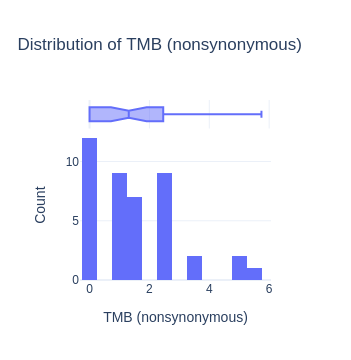

In [7]:
# Test the function 
fig = create_histogram(
    sample_df,
    variable="TMB (nonsynonymous)",
    bins=15
)

fig.show()

## Scatterplot function

In [8]:
def create_scatterplot(
    data,
    x_variable,
    y_variable,
    hover_columns=None,
    add_trendline=False,
    title=None
):
    if hover_columns is None:
        hover_columns = []

    if title is None:
        title = f"{y_variable} vs {x_variable}"

    trendline = "ols" if add_trendline else None

    figure = px.scatter(
        data,
        x=x_variable,
        y=y_variable,
        hover_data=hover_columns,
        trendline=trendline,
        title=title
    )

    figure.update_layout(
        template="plotly_white"
    )

    return figure

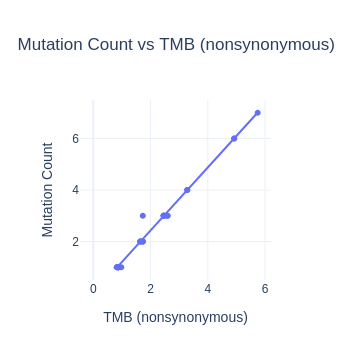

In [9]:
# Test the function 
fig = create_scatterplot(
    sample_df,
    x_variable="TMB (nonsynonymous)",
    y_variable="Mutation Count",
    hover_columns=[
        "Patient ID",
        "Sample ID"
    ],
    add_trendline=True
)

fig.show()

## Boxplot function

In [10]:
def create_boxplot(
    data,
    numeric_variable,
    category_variable=None,
    show_points=True,
    title=None
):
    points = "all" if show_points else False

    if category_variable is None:
        if title is None:
            title = f"Distribution of {numeric_variable}"

        figure = px.box(
            data,
            y=numeric_variable,
            points=points,
            title=title
        )

    else:
        if title is None:
            title = (
                f"{numeric_variable} by "
                f"{category_variable}"
            )

        figure = px.box(
            data,
            x=category_variable,
            y=numeric_variable,
            points=points,
            title=title
        )

    figure.update_layout(
        template="plotly_white"
    )

    return figure

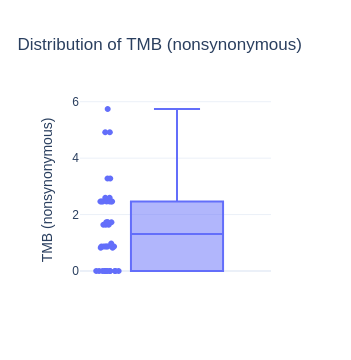

In [11]:
# Test one-variable boxplot 
fig = create_boxplot(
    sample_df,
    numeric_variable="TMB (nonsynonymous)"
)

fig.show()

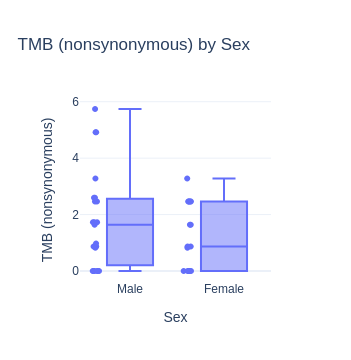

In [12]:
# Test grouped boxplot 
fig = create_boxplot(
    sample_df,
    numeric_variable="TMB (nonsynonymous)",
    category_variable="Sex"
)

fig.show()

## Violin plot function

In [13]:
def create_violin_plot(
    data,
    numeric_variable,
    category_variable=None,
    title=None
):
    if category_variable is None:
        if title is None:
            title = (
                f"Distribution of "
                f"{numeric_variable}"
            )

        figure = px.violin(
            data,
            y=numeric_variable,
            box=True,
            points="all",
            title=title
        )

    else:
        if title is None:
            title = (
                f"{numeric_variable} by "
                f"{category_variable}"
            )

        figure = px.violin(
            data,
            x=category_variable,
            y=numeric_variable,
            box=True,
            points="all",
            title=title
        )

    figure.update_layout(
        template="plotly_white"
    )

    return figure

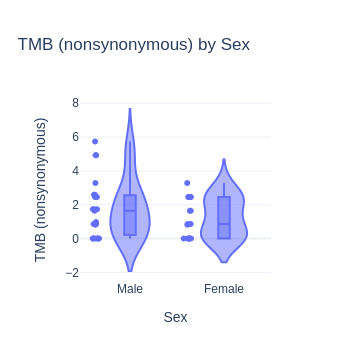

In [14]:
# Test the function 
fig = create_violin_plot(
    sample_df,
    numeric_variable="TMB (nonsynonymous)",
    category_variable="Sex"
)

fig.show()

## Correlation heatmap function 

In [15]:
def create_correlation_heatmap(
    data,
    variables=None,
    method="pearson",
    title=None
):
    if variables is None:
        variables = (
            data
            .select_dtypes(include=np.number)
            .columns
            .tolist()
        )

    correlation_matrix = (
        data[variables]
        .corr(method=method)
    )

    if title is None:
        title = (
            f"{method.title()} Correlation Matrix"
        )

    figure = px.imshow(
        correlation_matrix,
        text_auto=".2f",
        aspect="auto",
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        title=title
    )

    figure.update_layout(
        template="plotly_white"
    )

    return figure, correlation_matrix

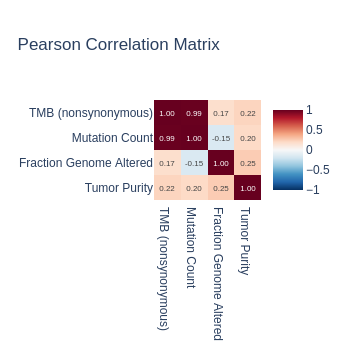

In [16]:
# Test selected variables 
correlation_variables = [
    "TMB (nonsynonymous)",
    "Mutation Count",
    "Fraction Genome Altered",
    "Tumor Purity"
]

available_correlation_variables = [
    variable
    for variable in correlation_variables
    if variable in sample_df.columns
]

fig, sample_correlation = (
    create_correlation_heatmap(
        sample_df,
        variables=available_correlation_variables
    )
)

fig.show()

## Categorical frequency plot function 

In [17]:
def create_frequency_plot(
    data,
    variable,
    title=None
):
    frequency_table = (
        data[variable]
        .fillna("Missing")
        .value_counts()
        .rename_axis(variable)
        .reset_index(name="Count")
    )

    if title is None:
        title = f"Frequency of {variable}"

    figure = px.bar(
        frequency_table,
        x=variable,
        y="Count",
        title=title
    )

    figure.update_layout(
        template="plotly_white",
        xaxis_title=variable,
        yaxis_title="Count"
    )

    return figure, frequency_table

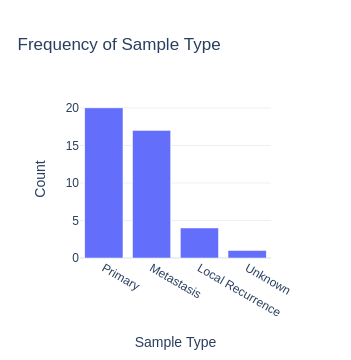

In [18]:
# Test the function
fig, sample_type_counts = create_frequency_plot(
    sample_df,
    variable="Sample Type"
)

fig.show()

# Sample-Level vs. Patient-Level Comparisons

## Compare TMB distributions

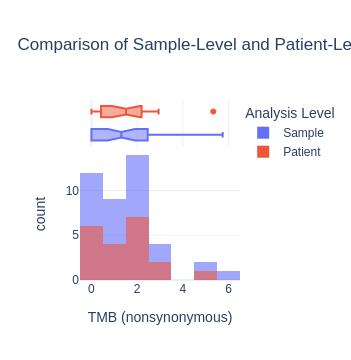

In [19]:
sample_tmb = sample_df[
    [
        "TMB (nonsynonymous)"
    ]
].copy()

sample_tmb["Analysis Level"] = "Sample"

patient_tmb = patient_df[
    [
        "TMB (nonsynonymous)"
    ]
].copy()

patient_tmb["Analysis Level"] = "Patient"

combined_tmb = pd.concat(
    [
        sample_tmb,
        patient_tmb
    ],
    ignore_index=True
)

fig = px.histogram(
    combined_tmb,
    x="TMB (nonsynonymous)",
    color="Analysis Level",
    barmode="overlay",
    marginal="box",
    opacity=0.6,
    title=(
        "Comparison of Sample-Level and "
        "Patient-Level TMB Distributions"
    )
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

This plot shows how averaging samples within each patient changes the distribution of TMB.

## Compare summary statistics

In [20]:
level_comparison = pd.DataFrame({
    "Metric": [
        "Observations",
        "Mean TMB",
        "Median TMB",
        "Minimum TMB",
        "Maximum TMB",
        "TMB Standard Deviation"
    ],
    "Sample Level": [
        len(sample_df),
        sample_df[
            "TMB (nonsynonymous)"
        ].mean(),
        sample_df[
            "TMB (nonsynonymous)"
        ].median(),
        sample_df[
            "TMB (nonsynonymous)"
        ].min(),
        sample_df[
            "TMB (nonsynonymous)"
        ].max(),
        sample_df[
            "TMB (nonsynonymous)"
        ].std()
    ],
    "Patient Level": [
        len(patient_df),
        patient_df[
            "TMB (nonsynonymous)"
        ].mean(),
        patient_df[
            "TMB (nonsynonymous)"
        ].median(),
        patient_df[
            "TMB (nonsynonymous)"
        ].min(),
        patient_df[
            "TMB (nonsynonymous)"
        ].max(),
        patient_df[
            "TMB (nonsynonymous)"
        ].std()
    ]
})

level_comparison

,Metric,Sample Level,Patient Level
0,Observations,42.000000,20.000000
1,Mean TMB,1.528860,1.522899
2,Median TMB,1.309707,1.515058
3,Minimum TMB,0.000000,0.000000
4,Maximum TMB,5.742431,5.332257
5,TMB Standard Deviation,1.460685,1.310156


## Display sample-level TMB by patient

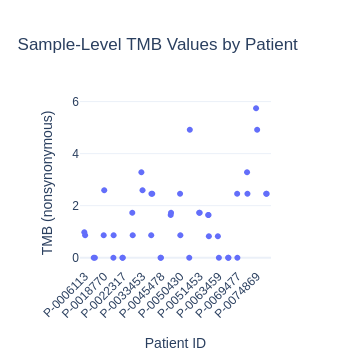

In [21]:
sample_plot_df = sample_df.sort_values(
    [
        "Patient ID",
        "TMB (nonsynonymous)"
    ]
)

fig = px.strip(
    sample_plot_df,
    x="Patient ID",
    y="TMB (nonsynonymous)",
    hover_data=["Sample ID"],
    title="Sample-Level TMB Values by Patient"
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

## Add patient mean to sample-level plot

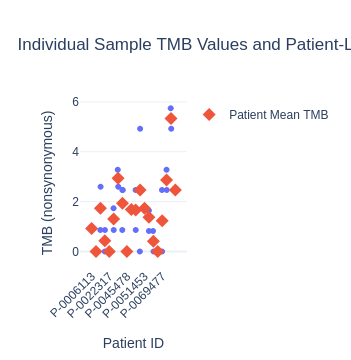

In [22]:
patient_mean_tmb = (
    sample_df
    .groupby("Patient ID", as_index=False)
    ["TMB (nonsynonymous)"]
    .mean()
)

fig = px.strip(
    sample_plot_df,
    x="Patient ID",
    y="TMB (nonsynonymous)",
    hover_data=["Sample ID"],
    title=(
        "Individual Sample TMB Values "
        "and Patient-Level Means"
    )
)

fig.add_trace(
    go.Scatter(
        x=patient_mean_tmb["Patient ID"],
        y=patient_mean_tmb[
            "TMB (nonsynonymous)"
        ],
        mode="markers",
        marker={
            "symbol": "diamond",
            "size": 10
        },
        name="Patient Mean TMB"
    )
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

# Missing-Data visualization

## Create a missing-value summary

In [23]:
missing_summary = (
    sample_df
    .isna()
    .sum()
    .rename("Missing Values")
    .reset_index()
    .rename(
        columns={
            "index": "Variable"
        }
    )
)

missing_summary["Percent Missing"] = (
    missing_summary["Missing Values"]
    / len(sample_df)
    * 100
)

missing_summary = missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

missing_summary.head(10)

,Variable,Missing Values,Percent Missing
10,Metastatic Site,27,64.285714
13,Mutation Count,12,28.571429
26,Tumor Purity,4,9.523810
3,Age at Which Sequencing was Reported (Years),3,7.142857
9,Institute Source,3,7.142857
23,Sex,2,4.761905
11,MSI Score,2,4.761905
18,Race Category,2,4.761905
12,MSI Type,2,4.761905
15,Overall Survival (Months),2,4.761905


## Plot missing values

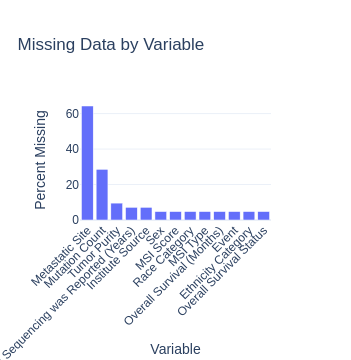

In [24]:
missing_plot_data = missing_summary[
    missing_summary[
        "Missing Values"
    ] > 0
]

if missing_plot_data.empty:
    print(
        "No missing values remain in the "
        "cleaned dataset."
    )
else:
    fig = px.bar(
        missing_plot_data,
        x="Variable",
        y="Percent Missing",
        hover_data=["Missing Values"],
        title="Missing Data by Variable"
    )

    fig.update_layout(
        template="plotly_white",
        xaxis_tickangle=-45,
        yaxis_title="Percent Missing"
    )

    fig.show()

# Survival Visualization

## Confirm survival groups

In [25]:
survival_df[
    "TMB Group"
].value_counts(
    dropna=False
)

TMB Group
Low TMB     10
High TMB     9
Name: count, dtype: int64

In [26]:
# If TMB Group is not present, recreate it:
if "TMB Group" not in survival_df.columns:
    median_tmb = survival_df[
        "TMB (nonsynonymous)"
    ].median()

    survival_df["TMB Group"] = (
        survival_df[
            "TMB (nonsynonymous)"
        ] > median_tmb
    ).map({
        True: "High TMB",
        False: "Low TMB"
    })

## Create a reusable Kaplan-Meier plotting function

In [27]:
def create_kaplan_meier_plot(
    data,
    group_column,
    duration_column,
    event_column,
    title
):
    figure = go.Figure()
    fitted_models = {}

    for group_name in sorted(
        data[group_column]
        .dropna()
        .unique()
    ):
        group_data = data[
            data[group_column] == group_name
        ]

        fitter = KaplanMeierFitter()

        fitter.fit(
            durations=group_data[
                duration_column
            ],
            event_observed=group_data[
                event_column
            ],
            label=group_name
        )

        fitted_models[group_name] = fitter

        survival_function = (
            fitter.survival_function_
        )

        confidence_interval = (
            fitter.confidence_interval_
        )

        figure.add_trace(
            go.Scatter(
                x=confidence_interval.index,
                y=confidence_interval.iloc[:, 1],
                mode="lines",
                line={"width": 0},
                hoverinfo="skip",
                showlegend=False
            )
        )

        figure.add_trace(
            go.Scatter(
                x=confidence_interval.index,
                y=confidence_interval.iloc[:, 0],
                mode="lines",
                line={"width": 0},
                fill="tonexty",
                opacity=0.2,
                hoverinfo="skip",
                showlegend=False
            )
        )

        figure.add_trace(
            go.Scatter(
                x=survival_function.index,
                y=survival_function.iloc[:, 0],
                mode="lines",
                line_shape="hv",
                name=group_name,
                hovertemplate=(
                    "Time: %{x:.1f} months"
                    "<br>Survival probability: %{y:.3f}"
                    "<extra></extra>"
                )
            )
        )

    figure.update_layout(
        title=title,
        xaxis_title="Overall Survival (Months)",
        yaxis_title="Survival Probability",
        yaxis={
            "range": [0, 1.05]
        },
        hovermode="x unified",
        template="plotly_white"
    )

    return figure, fitted_models

## Test the Kaplan-Meier function

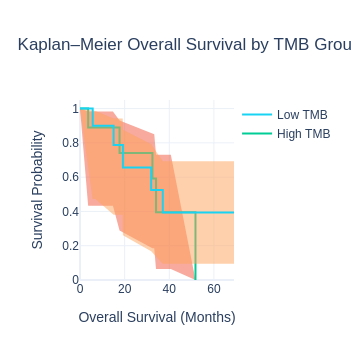

In [28]:
km_figure, km_models = (
    create_kaplan_meier_plot(
        data=survival_df,
        group_column="TMB Group",
        duration_column=(
            "Overall Survival (Months)"
        ),
        event_column="Event",
        title=(
            "Kaplan–Meier Overall Survival "
            "by TMB Group"
        )
    )
)

km_figure.show()

## Create a survival summary table

In [29]:
survival_summary_rows = []

for group_name, fitter in km_models.items():
    group_data = survival_df[
        survival_df["TMB Group"]
        == group_name
    ]

    survival_summary_rows.append({
        "TMB Group": group_name,
        "Patients": len(group_data),
        "Deaths": int(
            group_data["Event"].sum()
        ),
        "Censored": int(
            (
                group_data["Event"] == 0
            ).sum()
        ),
        "Median Survival Months": (
            fitter.median_survival_time_
        )
    })

survival_summary = pd.DataFrame(
    survival_summary_rows
)

survival_summary

,TMB Group,Patients,Deaths,Censored,Median Survival Months
0,High TMB,9,5,4,34.060
1,Low TMB,10,5,5,37.085


## Recalculate the log-rank test

In [30]:
high_tmb = survival_df[
    survival_df["TMB Group"]
    == "High TMB"
]

low_tmb = survival_df[
    survival_df["TMB Group"]
    == "Low TMB"
]

logrank_results = logrank_test(
    high_tmb[
        "Overall Survival (Months)"
    ],
    low_tmb[
        "Overall Survival (Months)"
    ],
    event_observed_A=high_tmb[
        "Event"
    ],
    event_observed_B=low_tmb[
        "Event"
    ]
)

print(
    "Log-rank statistic:",
    round(
        logrank_results.test_statistic,
        3
    )
)

print(
    "Log-rank p-value:",
    round(
        logrank_results.p_value,
        4
    )
)

Log-rank statistic: 0.072
Log-rank p-value: 0.7886


# Streamlit Control Planning

## Define proposed exploratory-analysis controls

In [31]:
exploratory_controls = pd.DataFrame({
    "Visualization": [
        "Histogram",
        "Scatterplot",
        "Boxplot",
        "Violin Plot",
        "Correlation Heatmap",
        "Categorical Bar Chart"
    ],
    "Required Controls": [
        "Analysis level, numeric variable, bins",
        (
            "Analysis level, X variable, "
            "Y variable, trendline"
        ),
        (
            "Analysis level, numeric variable, "
            "optional category"
        ),
        (
            "Analysis level, numeric variable, "
            "optional category"
        ),
        (
            "Analysis level, selected numeric "
            "variables, correlation method"
        ),
        "Analysis level, categorical variable"
    ],
    "Recommended Download": [
        "HTML or PNG",
        "HTML or PNG",
        "HTML or PNG",
        "HTML or PNG",
        "CSV matrix and plot",
        "CSV frequency table and plot"
    ]
})

exploratory_controls

,Visualization,Required Controls,Recommended Download
0,Histogram,"Analysis level, numeric variable, bins",HTML or PNG
1,Scatterplot,"Analysis level, X variable, Y variable, trendline",HTML or PNG
2,Boxplot,"Analysis level, numeric variable, optional cat...",HTML or PNG
3,Violin Plot,"Analysis level, numeric variable, optional cat...",HTML or PNG
4,Correlation Heatmap,"Analysis level, selected numeric variables, co...",CSV matrix and plot
5,Categorical Bar Chart,"Analysis level, categorical variable",CSV frequency table and plot


## Define proposed survival-analysis controls

In [32]:
survival_controls = pd.DataFrame({
    "Control": [
        "Analysis level",
        "Patient TMB aggregation",
        "TMB grouping method",
        "Custom cutoff",
        "Confidence intervals",
        "Display survival table"
    ],
    "Options": [
        "Patient or Sample",
        "Mean, median, minimum, maximum",
        "Median, custom cutoff, quartiles",
        "Numeric input",
        "Show or hide",
        "Show or hide"
    ],
    "Default": [
        "Patient",
        "Mean",
        "Median",
        "Median TMB",
        "Show",
        "Show"
    ]
})

survival_controls

,Control,Options,Default
0,Analysis level,Patient or Sample,Patient
1,Patient TMB aggregation,"Mean, median, minimum, maximum",Mean
2,TMB grouping method,"Median, custom cutoff, quartiles",Median
3,Custom cutoff,Numeric input,Median TMB
4,Confidence intervals,Show or hide,Show
5,Display survival table,Show or hide,Show


# Figure Export

## Export selected figures

In [33]:
tmb_histogram = create_histogram(
    sample_df,
    variable="TMB (nonsynonymous)"
)

tmb_histogram.write_html(
    FIGURE_DIR
    / "sample_tmb_histogram.html"
)

In [34]:
# Export the sample-level scatterplot:
tmb_mutation_scatter = create_scatterplot(
    sample_df,
    x_variable="TMB (nonsynonymous)",
    y_variable="Mutation Count",
    hover_columns=[
        "Patient ID",
        "Sample ID"
    ],
    add_trendline=True
)

tmb_mutation_scatter.write_html(
    FIGURE_DIR
    / "tmb_mutation_count_scatter.html"
)

In [35]:
# Export the correlation heatmap:
correlation_figure, correlation_table = (
    create_correlation_heatmap(
        sample_df,
        variables=available_correlation_variables
    )
)

correlation_figure.write_html(
    FIGURE_DIR
    / "sample_correlation_heatmap.html"
)

In [36]:
# Export the Kaplan–Meier figure:
km_figure.write_html(
    FIGURE_DIR
    / "kaplan_meier_tmb.html"
)

## Export supporting tables

In [37]:
TABLE_DIR = (
    PROJECT_DIR
    / "results"
    / "visualization_tables"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

level_comparison.to_csv(
    TABLE_DIR
    / "sample_patient_level_comparison.csv",
    index=False
)

missing_summary.to_csv(
    TABLE_DIR
    / "missing_data_summary.csv",
    index=False
)

survival_summary.to_csv(
    TABLE_DIR
    / "survival_group_summary.csv",
    index=False
)

correlation_table.to_csv(
    TABLE_DIR
    / "correlation_matrix.csv"
)

exploratory_controls.to_csv(
    TABLE_DIR
    / "exploratory_streamlit_controls.csv",
    index=False
)

survival_controls.to_csv(
    TABLE_DIR
    / "survival_streamlit_controls.csv",
    index=False
)

## Confirm exported files

In [38]:
print("Interactive figures:")

for file_path in sorted(
    FIGURE_DIR.iterdir()
):
    print(file_path.name)

print("\nVisualization tables:")

for file_path in sorted(
    TABLE_DIR.iterdir()
):
    print(file_path.name)

Interactive figures:
kaplan_meier_tmb.html
sample_correlation_heatmap.html
sample_tmb_histogram.html
tmb_mutation_count_scatter.html

Visualization tables:
correlation_matrix.csv
exploratory_streamlit_controls.csv
missing_data_summary.csv
sample_patient_level_comparison.csv
survival_group_summary.csv
survival_streamlit_controls.csv


# Recommended Streamlit layout 

Sidebar

Analysis Selection
• Data Overview
• Exploratory Analysis
• Survival Analysis

Exploratory Analysis Controls
• Analysis level: Sample or Patient
• Visualization type
• X variable
• Y variable
• Category variable
• Number of histogram bins
• Add trendline
• Correlation method

Survival Analysis Controls
• Analysis level
• Patient TMB aggregation method
• TMB grouping method
• Custom TMB cutoff
• Display confidence intervals
• Display analysis dataset

# Conclusions

• Plotly figures were successfully generated for both sample-level and patient-level datasets.

• Histograms and boxplots are useful for examining variable distributions and identifying potential outliers.

• Scatterplots allow users to evaluate relationships among TMB, mutation count, fraction genome altered, tumor purity, and other quantitative variables.

• Correlation heatmaps summarize relationships among multiple genomic and clinical variables.

• Categorical frequency plots can display sample type, sex, race, cancer subtype, and other clinical characteristics.

• Sample-level plots reveal within-patient variation that is hidden after patient-level aggregation.

• Patient-level analysis remains the appropriate default for survival analysis because each patient should contribute only one independent observation.

• Kaplan–Meier curves, confidence intervals, log-rank results, and group summary tables can all be incorporated into the Streamlit application.

• Reusable plotting functions developed in this notebook can later be moved into the scripts directory with minimal modification.

• The final application should allow users to select the analysis level, visualization type, variables, TMB aggregation method, and TMB grouping method.